In [1]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='data', train=False, download=True, transform=transform)

print("Tamaño del set de entrenamiento:", len(train_data))
print("Tamaño del set de prueba:", len(test_data))


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]

Tamaño del set de entrenamiento: 60000
Tamaño del set de prueba: 10000


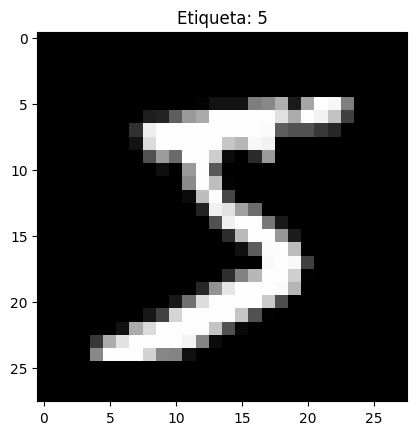

In [2]:
import matplotlib.pyplot as plt

image, label = train_data[0]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Etiqueta: {label}")
plt.show()


In [3]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(train_data))
val_size   = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

batch_size = 64

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=batch_size)
test_loader  = DataLoader(test_data, batch_size=batch_size)


In [4]:
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

In [5]:
import torch

# 1. ¿CUDA está disponible?
cuda_available = torch.cuda.is_available()
print(f"CUDA disponible: {cuda_available}")

if cuda_available:
    # 2. ¿Cuántas GPUs detecta?
    num_devices = torch.cuda.device_count()
    print(f"Número de dispositivos CUDA: {num_devices}")

    # 3. Nombre de la GPU 0 (la primera)
    gpu0_name = torch.cuda.get_device_name(0)
    print(f"Nombre del dispositivo 0: {gpu0_name}")

    # 4. Índice del dispositivo actual
    current = torch.cuda.current_device()
    print(f"Dispositivo CUDA actual: {current}")

    # 5. Verificar que un tensor esté en GPU
    x = torch.randn(3, 3).to('cuda')  # lo movemos a CUDA
    print(f"¿El tensor 'x' está en GPU? {x.is_cuda}")
    print(f"Dispositivo de 'x': {x.device}")
else:
    print("No hay GPU CUDA disponible, todo irá en CPU.")


CUDA disponible: True
Número de dispositivos CUDA: 1
Nombre del dispositivo 0: Tesla T4
Dispositivo CUDA actual: 0
¿El tensor 'x' está en GPU? True
Dispositivo de 'x': cuda:0


In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
# Guardamos los resultados para comparación posterior
train_losses_basic, val_losses_basic, accuracies_basic = [], [], []

epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
# Entrenamiento del modelo básico
for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses_basic.append(running_loss / len(train_loader))

    # Validación
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            val_loss += criterion(output, labels).item()
            _, predicted = torch.max(output.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses_basic.append(val_loss / len(val_loader))
    accuracy = correct / total
    accuracies_basic.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses_basic[-1]:.4f}, Val Loss: {val_losses_basic[-1]:.4f}, Val Accuracy: {accuracy:.4f}")


Epoch 1/10, Train Loss: 0.4791, Val Loss: 0.2789, Val Accuracy: 0.9143
Epoch 2/10, Train Loss: 0.2516, Val Loss: 0.1950, Val Accuracy: 0.9417
Epoch 3/10, Train Loss: 0.1983, Val Loss: 0.1764, Val Accuracy: 0.9470
Epoch 4/10, Train Loss: 0.1723, Val Loss: 0.1371, Val Accuracy: 0.9592
Epoch 5/10, Train Loss: 0.1566, Val Loss: 0.1490, Val Accuracy: 0.9567
Epoch 6/10, Train Loss: 0.1418, Val Loss: 0.1221, Val Accuracy: 0.9633
Epoch 7/10, Train Loss: 0.1332, Val Loss: 0.1510, Val Accuracy: 0.9557
Epoch 8/10, Train Loss: 0.1293, Val Loss: 0.1118, Val Accuracy: 0.9661
Epoch 9/10, Train Loss: 0.1186, Val Loss: 0.1194, Val Accuracy: 0.9637
Epoch 10/10, Train Loss: 0.1117, Val Loss: 0.1172, Val Accuracy: 0.9673


In [9]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5)
X = torch.stack([train_data[i][0] for i in range(len(train_data))])
y = torch.tensor([train_data[i][1] for i in range(len(train_data))])


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        output = model(images)
        _, preds = torch.max(output, 1)
        all_preds.extend(preds.cpu())
        all_labels.extend(labels)

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.99      0.98      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.95      0.99      0.97       982
           5       0.98      0.94      0.96       892
           6       0.99      0.95      0.97       958
           7       0.98      0.95      0.97      1028
           8       0.94      0.98      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



<Axes: >

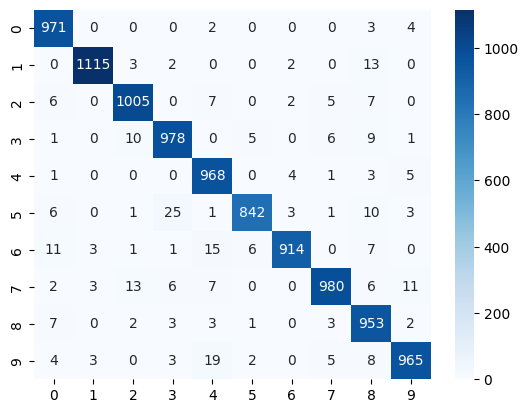

In [11]:
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')


In [12]:
from torchvision import models

model_ft = models.resnet18(pretrained=True)

# Congelar todas las capas
for param in model_ft.parameters():
    param.requires_grad = False

# Reemplazar capa final
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 10)  # 10 clases

model_ft.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
optimizer = optim.Adam(model_ft.fc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Entrenamiento similar al anterior pero solo con la capa final

In [15]:
# Get the first convolutional layer
original_conv = model_ft.conv1

# Create a new convolutional layer with 1 input channel
new_conv = nn.Conv2d(1, original_conv.out_channels,
                     kernel_size=original_conv.kernel_size,
                     stride=original_conv.stride,
                     padding=original_conv.padding,
                     bias=original_conv.bias)

# Optional: Copy/average weights (simple averaging for grayscale)
# If you want to use the pre-trained weights as much as possible for the 1 channel:
# new_conv.weight.data = original_conv.weight.data.mean(dim=1, keepdim=True)
# If you prefer random initialization for the new layer:
nn.init.kaiming_normal_(new_conv.weight, mode='fan_out', nonlinearity='relu')

# Replace the original convolutional layer with the new one
model_ft.conv1 = new_conv

model_ft.to(device) # Move the modified model to the device

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
for param in model_ft.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model_ft.parameters(), lr=1e-5)


In [18]:
# Guardamos los resultados para comparación posterior
train_losses_ft_only_fc, val_losses_ft_only_fc, accuracies_ft_only_fc = [], [], []

# Entrenamiento similar al anterior pero solo con la capa final
for epoch in range(epochs):
    model_ft.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model_ft(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses_ft_only_fc.append(running_loss / len(train_loader))

    # Validación
    model_ft.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            output = model_ft(images)
            val_loss += criterion(output, labels).item()
            _, predicted = torch.max(output.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses_ft_only_fc.append(val_loss / len(val_loader))
    accuracy = correct / total
    accuracies_ft_only_fc.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss (FC only): {train_losses_ft_only_fc[-1]:.4f}, Val Loss (FC only): {val_losses_ft_only_fc[-1]:.4f}, Val Accuracy (FC only): {accuracy:.4f}")

Epoch 1/10, Train Loss (FC only): 0.6767, Val Loss (FC only): 0.3739, Val Accuracy (FC only): 0.8862
Epoch 2/10, Train Loss (FC only): 0.2984, Val Loss (FC only): 0.2238, Val Accuracy (FC only): 0.9307
Epoch 3/10, Train Loss (FC only): 0.1878, Val Loss (FC only): 0.1649, Val Accuracy (FC only): 0.9497
Epoch 4/10, Train Loss (FC only): 0.1368, Val Loss (FC only): 0.1364, Val Accuracy (FC only): 0.9598
Epoch 5/10, Train Loss (FC only): 0.0990, Val Loss (FC only): 0.1199, Val Accuracy (FC only): 0.9650
Epoch 6/10, Train Loss (FC only): 0.0762, Val Loss (FC only): 0.1075, Val Accuracy (FC only): 0.9681
Epoch 7/10, Train Loss (FC only): 0.0611, Val Loss (FC only): 0.1009, Val Accuracy (FC only): 0.9710
Epoch 8/10, Train Loss (FC only): 0.0476, Val Loss (FC only): 0.0953, Val Accuracy (FC only): 0.9738
Epoch 9/10, Train Loss (FC only): 0.0376, Val Loss (FC only): 0.0893, Val Accuracy (FC only): 0.9752
Epoch 10/10, Train Loss (FC only): 0.0301, Val Loss (FC only): 0.0890, Val Accuracy (FC onl

In [24]:
model_ft.eval()  # Evaluación del modelo ResNet

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        output = model_ft(images)
        _, preds = torch.max(output, 1)
        all_preds.extend(preds.cpu())
        all_labels.extend(labels)

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.96      0.97       982
           5       0.98      0.98      0.98       892
           6       0.97      0.97      0.97       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.95      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



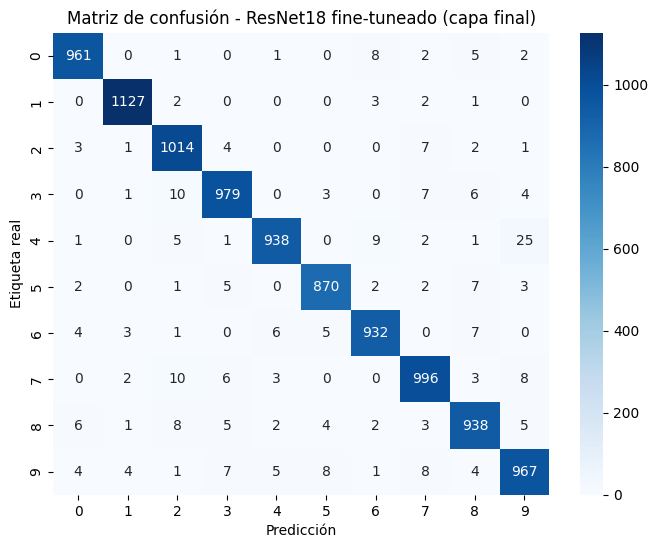

In [25]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión - ResNet18 fine-tuneado (capa final)")
plt.show()

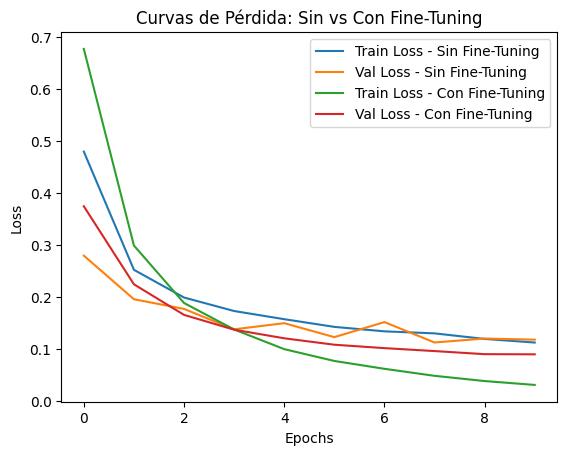

In [26]:
import matplotlib.pyplot as plt

# Curvas de pérdida
plt.plot(range(epochs), train_losses_basic, label='Train Loss - Sin Fine-Tuning')
plt.plot(range(epochs), val_losses_basic, label='Val Loss - Sin Fine-Tuning')
plt.plot(range(epochs), train_losses_ft_only_fc, label='Train Loss - Con Fine-Tuning')
plt.plot(range(epochs), val_losses_ft_only_fc, label='Val Loss - Con Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Curvas de Pérdida: Sin vs Con Fine-Tuning')
plt.show()

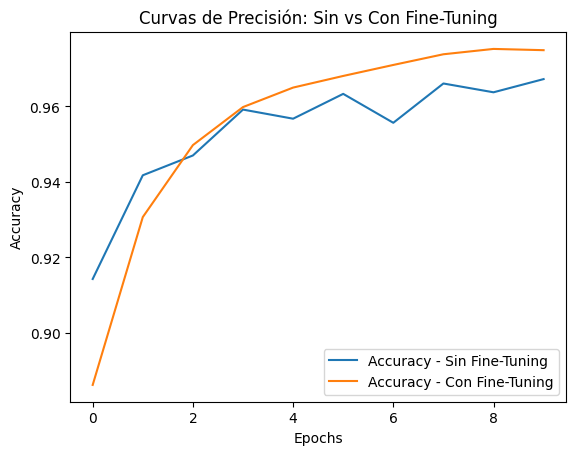

In [27]:
# Curvas de precisión
plt.plot(range(epochs), accuracies_basic, label='Accuracy - Sin Fine-Tuning')
plt.plot(range(epochs), accuracies_ft_only_fc, label='Accuracy - Con Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Curvas de Precisión: Sin vs Con Fine-Tuning')
plt.show()

In [22]:
import os
os.makedirs("modelos", exist_ok=True)
torch.save(model.state_dict(), "modelos/modelo_final.pth")

In [23]:
model.load_state_dict(torch.load("modelos/modelo_final.pth"))
model.eval()


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=10, bias=True)
)